In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer

In [ ]:
df=pd.read_csv('/content/nlp_dataset.csv')
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'because', 'she', 'whom', 'you', 'itself', "hasn't", 'he', 'mightn', 'all', 'which', 'its', "wouldn't", 'haven', "don't", "mightn't", 'there', 'weren', 'between', 'wouldn', 'shouldn', "he'd", 'i', "it'll", "she'd", "won't", 'each', "didn't", 'under', 'hasn', "we're", 'be', "she'll", 've', 'doing', "wasn't", "doesn't", 'me', 'own', "needn't", "couldn't", "mustn't", 'had', 'myself', 'again', 'll', 'now', "they'll", 'nor', 'ain', 'his', 'our', 'y', 'more', 'through', 'where', 'doesn', 'what', "should've", 'they', 'to', "he's", "you'd", 'as', 'here', 'for', 'and', "weren't", "shan't", 'mustn', 'into', 'd', 'yourself', 'having', 'my', 'm', 'am', 'were', "it'd", 'these', 'until', 'aren', "we'll", 'against', 're', 'this', 'while', "haven't", 'on', 'her', 'those', "i've", 'from', 'hadn', "isn't", 'any', 'most', 'then', 'too', 'when', 'is', 'very', 'has', 'above', 'just', 'how', 'if', 'in', 'of', 'shan', "you'll", "he'll", 'themselves', 'we', "i'll", 'are', 'himself', 'some', 'below', 'not', "

In [ ]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_words=[word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_words=[lemmatizer.lemmatize(word.lower()) for word in filtered_words]

  return{

         "Original_text":text,
         "Word_tokens":word_tokens,
         "filtered_words":filtered_words,
         "Lemmatized_words":lemmatized_words
  }


In [ ]:
results=df['Text'].apply(process_text)
processed_df=pd.DataFrame(results.tolist())
processed_df.head()

processed_file_path="processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print("Processed data saved to",processed_file_path)

Processed data saved to processed_nlp_dataset.csv


In [ ]:
processed_df.head()

,Original_text,Word_tokens,filtered_words,Lemmatized_words
0,Natural Language Processing is a fascinating f...,"[Natural, Language, Processing, is, a, fascina...","[Natural, Language, Processing, fascinating, f...","[natural, language, processing, fascinating, f..."
1,It bridges the gap between humans and machines...,"[It, bridges, the, gap, between, humans, and, ...","[bridges, gap, humans, machines, enabling, com...","[bridge, gap, human, machine, enabling, comput..."
2,NLP techniques are widely used in applications...,"[NLP, techniques, are, widely, used, in, appli...","[NLP, techniques, widely, used, applications, ...","[nlp, technique, widely, used, application, ch..."
3,Machine translation and speech recognition are...,"[Machine, translation, and, speech, recognitio...","[Machine, translation, speech, recognition, co...","[machine, translation, speech, recognition, co..."
4,"Despite its advancements, NLP faces challenges...","[Despite, its, advancements, ,, NLP, faces, ch...","[Despite, advancements, ,, NLP, faces, challen...","[despite, advancement, ,, nlp, face, challenge..."


In [ ]:
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [ ]:
text_data=[
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
]

In [ ]:
vectorizer=CountVectorizer()

bow_matrix=vectorizer.fit_transform(text_data)
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bags of words representation")
print(bow_df)

Bags of words representation
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...          

In [ ]:
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nbag of words saved as 'bag_of_words.csv'.")


bag of words saved as 'bag_of_words.csv'.


In [ ]:
print(bow_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>
  Coords	Values
  (0, 39)	1
  (0, 34)	1
  (0, 43)	1
  (0, 31)	1
  (0, 21)	1
  (0, 22)	1
  (0, 41)	1
  (0, 6)	1
  (0, 30)	1
  (1, 34)	1
  (1, 32)	1
  (1, 9)	1
  (1, 52)	1
  (1, 23)	1
  (1, 8)	1
  (1, 25)	1
  (1, 3)	1
  (1, 36)	1
  (1, 10)	1
  (1, 18)	1
  (1, 15)	1
  (1, 53)	1
  (1, 55)	1
  (1, 24)	1
  (2, 3)	1
  :	:
  (4, 0)	1
  (4, 20)	1
  (4, 12)	1
  (4, 28)	1
  (4, 1)	1
  (5, 3)	1
  (5, 40)	1
  (5, 5)	1
  (5, 16)	1
  (5, 46)	1
  (5, 29)	1
  (5, 26)	1
  (5, 44)	1
  (6, 31)	1
  (6, 41)	1
  (6, 32)	1
  (6, 52)	1
  (6, 40)	1
  (6, 27)	1
  (6, 42)	1
  (6, 58)	1
  (6, 37)	1
  (6, 19)	1
  (6, 38)	1
  (6, 51)	1


In [ ]:
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()

def lemmatize_text(Text):
  tokens=word_tokenize(str(Text))
  return '  '.join([lemmatizer.lemmatize(word)for word in tokens])


def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return '  '.join([stemmer.stem(word)for word in tokens])

In [ ]:
df['lemmatized_text']=df['Text'].apply(lemmatize_text)
df['stemmed_text']=df['Text'].apply(stem_text)

In [ ]:
df

,Text,lemmatized_text,stemmed_text
0,Natural Language Processing is a fascinating f...,Natural Language Processing is a fascinat...,natur languag process is a fascin field ...
1,It bridges the gap between humans and machines...,It bridge the gap between human and mac...,it bridg the gap between human and mach...
2,NLP techniques are widely used in applications...,NLP technique are widely used in applica...,nlp techniqu are wide use in applic suc...
3,Machine translation and speech recognition are...,Machine translation and speech recognition...,machin translat and speech recognit are ...
4,"Despite its advancements, NLP faces challenges...","Despite it advancement , NLP face challe...","despit it advanc , nlp face challeng in..."
5,Continuous research and innovation are improvi...,Continuous research and innovation are im...,continu research and innov are improv nl...
6,"The potential of NLP is vast, making it essent...","The potential of NLP is vast , making ...","the potenti of nlp is vast , make it ..."


In [ ]:
output_path="lemmatization_vs_stemming.csv"
df.to_csv(output_path,index=False)
print("lemmatization and stemming results saved to",output_path)

print(df[['Text','lemmatized_text','stemmed_text']])


lemmatization and stemming results saved to lemmatization_vs_stemming.csv
                                                Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  Natural  Language  Processing  is  a  fascinat...   
1  It  bridge  the  gap  between  human  and  mac...   
2  NLP  technique  are  widely  used  in  applica...   
3  Machine  translation  and  speech  recognition...   
4  Despite  it  advancement  ,  NLP  face  challe...   
5  Continuous  research  and  innovation  are  im...   
6  The  potential  of  NLP  is  vast  ,  making  ...   

                            

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
df

,Text,lemmatized_text,stemmed_text
0,Natural Language Processing is a fascinating f...,Natural Language Processing is a fascinat...,natur languag process is a fascin field ...
1,It bridges the gap between humans and machines...,It bridge the gap between human and mac...,it bridg the gap between human and mach...
2,NLP techniques are widely used in applications...,NLP technique are widely used in applica...,nlp techniqu are wide use in applic suc...
3,Machine translation and speech recognition are...,Machine translation and speech recognition...,machin translat and speech recognit are ...
4,"Despite its advancements, NLP faces challenges...","Despite it advancement , NLP face challe...","despit it advanc , nlp face challeng in..."
5,Continuous research and innovation are improvi...,Continuous research and innovation are im...,continu research and innov are improv nl...
6,"The potential of NLP is vast, making it essent...","The potential of NLP is vast , making ...","the potenti of nlp is vast , make it ..."


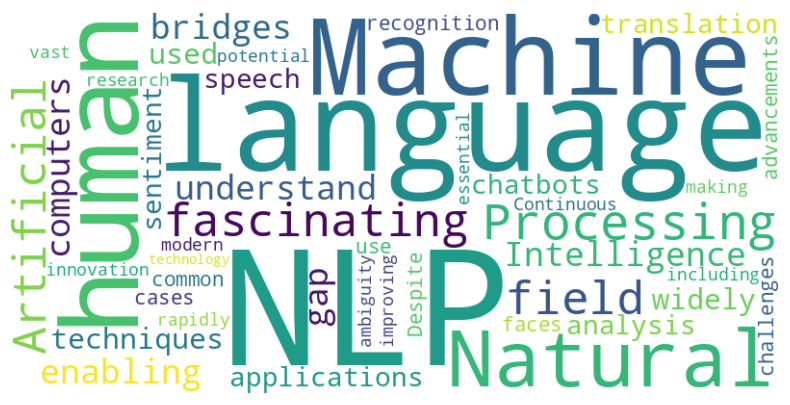

In [ ]:
text_data=" ".join(df['Text'].dropna())
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()